## HDI Cross-Country Analysis (2022): A Multi-Source Data Pipeline & Structural Audit
Notebook 03: EDA 

**Goal:** Conduct a comprehensive audit of the integrated dataset to evaluate signal distributions, identify non-linearities, and verify the structural alignment of multi-source indicators (World Bank & UNDP) before moving to the validation pipeline.

Input Source: `processed_data/master_dataset.csv`

Workflow:

1. Descriptive Baseline: Statistical summary of raw metrics.
2. Distribution Audit: Identifying skewness and transformation requirements.
3. Cross-Source Correlation: Verifying linear alignment between external features and the target index.
4. Outlier Assessment: Determining the influence of extreme country-level observations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path("..").resolve()
PROCESSED_DATA = BASE_DIR / "processed_data"

# Load master dataset
master = pd.read_csv(PROCESSED_DATA / "master_dataset.csv")

print(f"Shape: {master.shape}")
master.head()

Shape: (186, 11)


,country_code,country,hdi,gdp_per_capita,mean_years_schooling,education_expenditure_pct_gdp,health_expenditure_per_capita,government_effectiveness,gii,region,income_level
0,AFG,Afghanistan,0.462,377.665627,2.514790,NaN,80.651604,-1.880035,0.665,Middle East & North Africa,Low income
1,AGO,Angola,0.591,2860.902519,5.844292,2.385359,103.945061,-1.026034,0.520,Sub-Saharan Africa,Lower middle income
2,ALB,Albania,0.789,5867.650962,10.121144,2.729770,506.869202,0.064541,0.116,Europe & Central Asia,Upper middle income
3,AND,Andorra,0.884,39780.415299,11.613440,2.647280,3190.113281,1.495261,NaN,Europe & Central Asia,High income
4,ARE,United Arab Emirates,0.937,41828.555330,12.773750,NaN,2240.905029,1.299128,0.035,Middle East & North Africa,High income


## I. Descriptive Baseline

In [2]:
# Descriptive statistics
print(master.describe().round(3))


           hdi  gdp_per_capita  mean_years_schooling  \
count  186.000         186.000               186.000   
mean     0.726       14383.572                 9.034   
std      0.152       19714.079                 3.205   
min      0.380         263.588                 1.341   
25%      0.608        2025.258                 6.546   
50%      0.740        5937.249                 9.336   
75%      0.846       17433.988                11.646   
max      0.967      107467.187                14.256   

       education_expenditure_pct_gdp  health_expenditure_per_capita  \
count                        152.000                        186.000   
mean                           4.288                       1304.993   
std                            2.080                       2088.685   
min                            0.000                         15.858   
25%                            2.955                        101.346   
50%                            4.068                        446.673  

## II. Distribution & Skewness Assessment

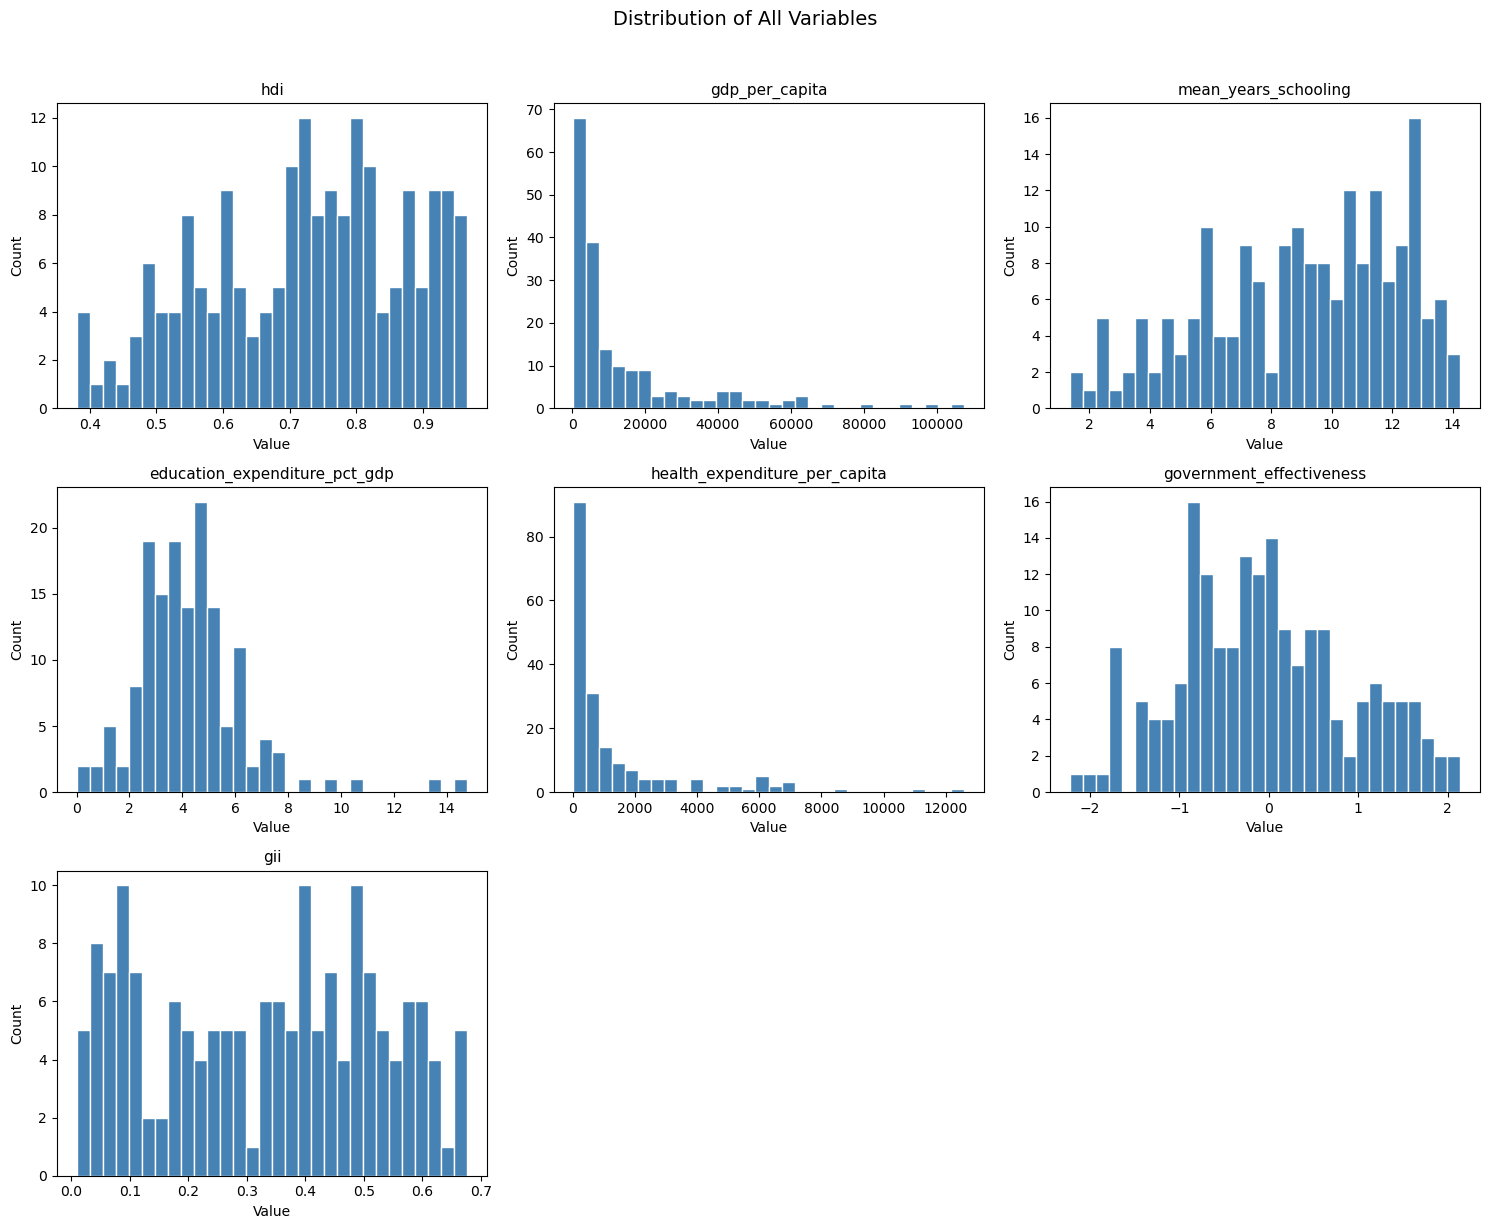

In [3]:
# Distribution plots for all numerical variables
num_vars = ['hdi', 'gdp_per_capita', 'mean_years_schooling',
            'education_expenditure_pct_gdp', 'health_expenditure_per_capita',
            'government_effectiveness', 'gii']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    axes[i].hist(master[var].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide empty subplots 
for j in range(len(num_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of All Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Distribution analysis and Skewness Audit

- gdp_per_capita & health_expenditure_per_capita: Heavily right-skewed, driven by high-income/high-spending countries. A log transformation is required to stabilize variance and reduce the influence of extreme values in the regression model.

- *HDI & government_effectiveness: Approximately normally distributed, reflecting the global spread of development and WGI methodology. No transformation required.

- GII (Gender Inequality Index): Displays a bimodal distribution, indicating two distinct clusters of countries. This pattern suggests a high-contrast signal that may influence regression behavior or justify regional stratification.

## III. Cross-Source Correlation Audit
Validate the linear alignment between indicators merged from different sources. High correlation between UNDP indicators (HDI) and World Bank indicators (GDP).

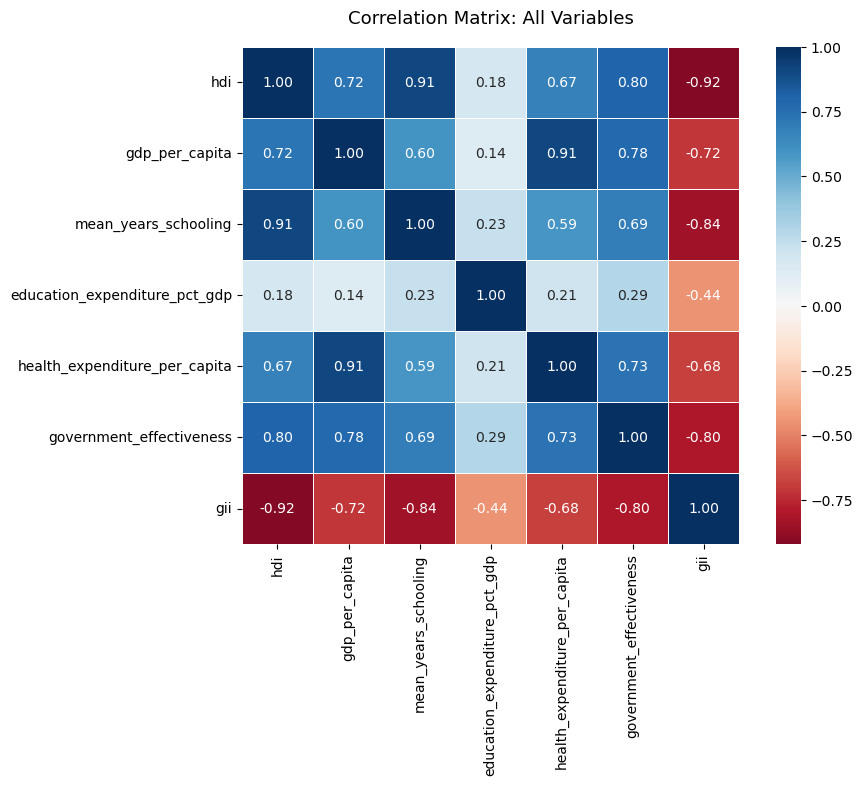

In [4]:
# Correlation matrix
corr_vars = ['hdi', 'gdp_per_capita', 'mean_years_schooling',
             'education_expenditure_pct_gdp', 'health_expenditure_per_capita',
             'government_effectiveness', 'gii']

corr_matrix = master[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu',        #  blue=positive, red=negative
            center=0,
            square=True,
            linewidths=0.5)     

plt.title('Correlation Matrix: All Variables', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### Key Finding: Cross-Source Signal Alignment (Correlation)

Extremely high alignment (0.91) between mean_years_schooling (UNDP) and the target hdi.

**Implication:** This serves as a Structural Integrity Check. It confirms that the data merged from separate API sources maintains the mathematical logic of the human development framework.

**Risk Identification:** The 0.91 correlation between GDP and Health spending identifies Functional Redundancy. This justifies the formal VIF Redundancy Audit in the next notebook to ensure stable coefficient attribution.

## IV. Outlier & Leverage Assessment

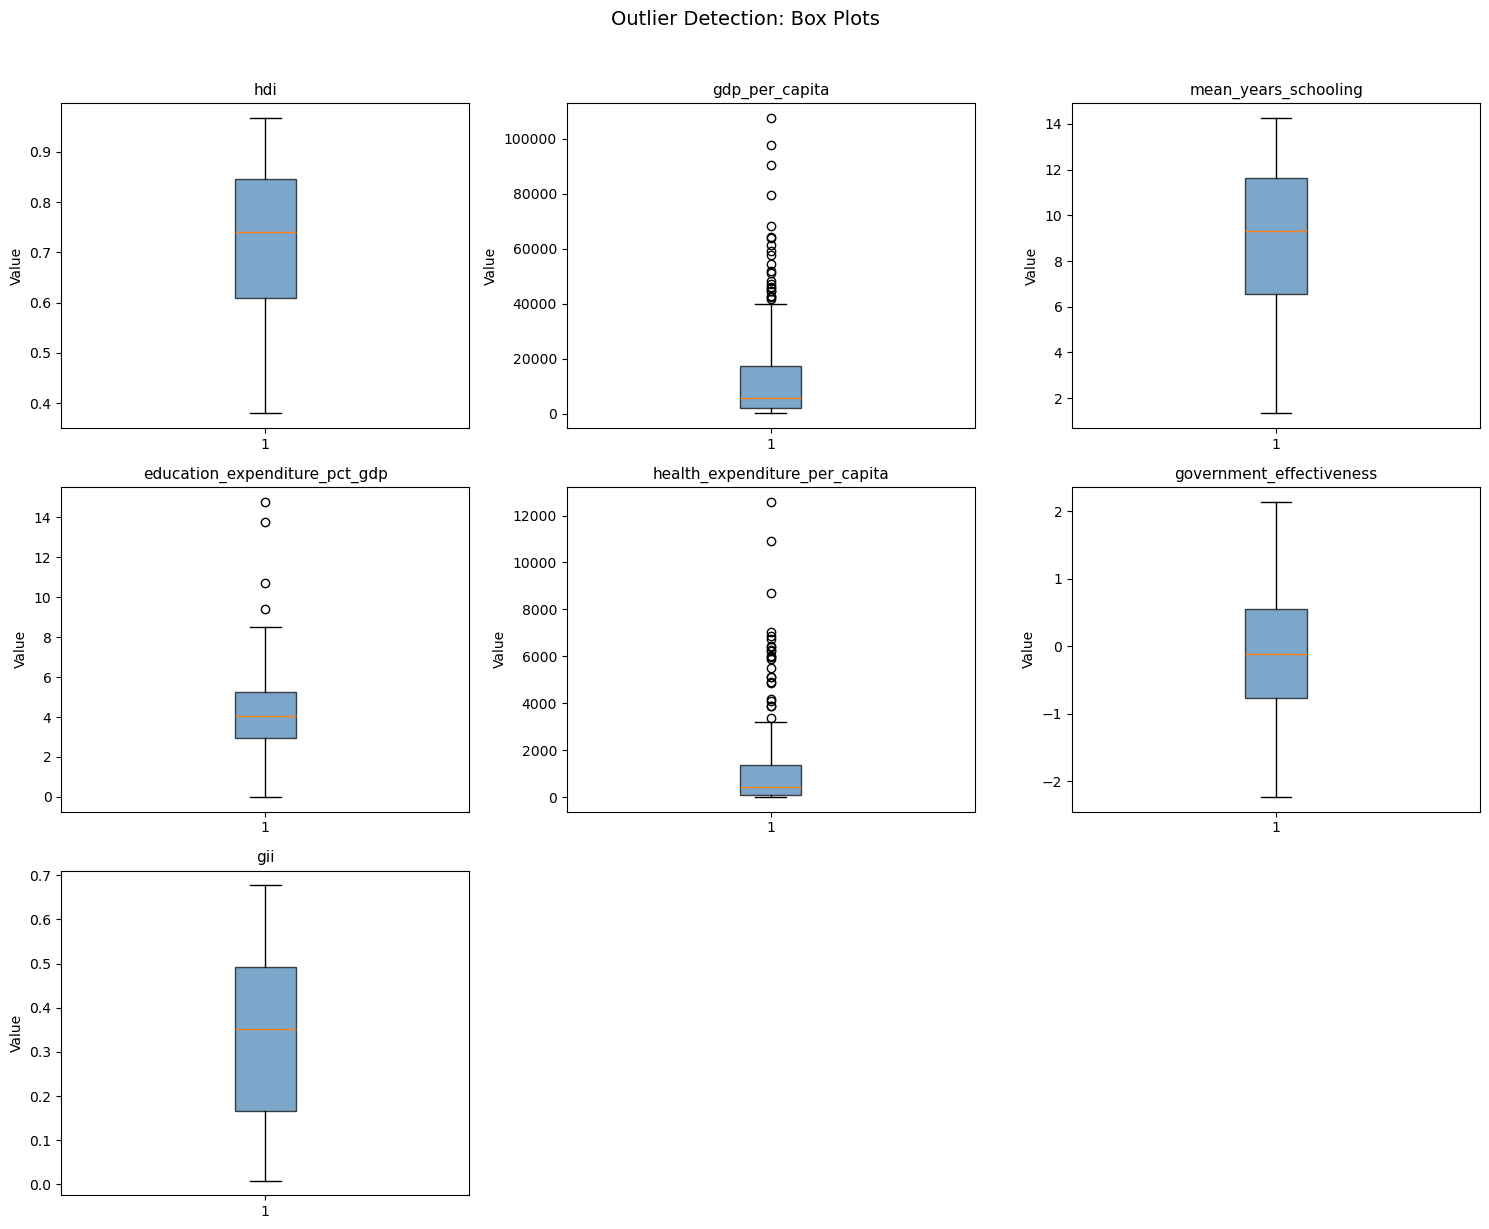

In [ ]:
# Box plots for outlier detection 
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(num_vars):
    axes[i].boxplot(master[var].dropna(), 
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(var, fontsize=11)
    axes[i].set_ylabel('Value')

for j in range(len(num_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection: Box Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Key Finding: Outlier & Leverage Audit

**Observation:** gdp_per_capita and health_expenditure show significant upper-tail outliers (High-income nations like Luxembourg and Singapore).

**Implication:** These are verified as High-Leverage Points rather than errors. Removing them would lose critical global variation; therefore, the pipeline is designed to retain them but mitigate their influence through Log-Linearization rather than deletion.


## V. Bivariate Linearity Validation

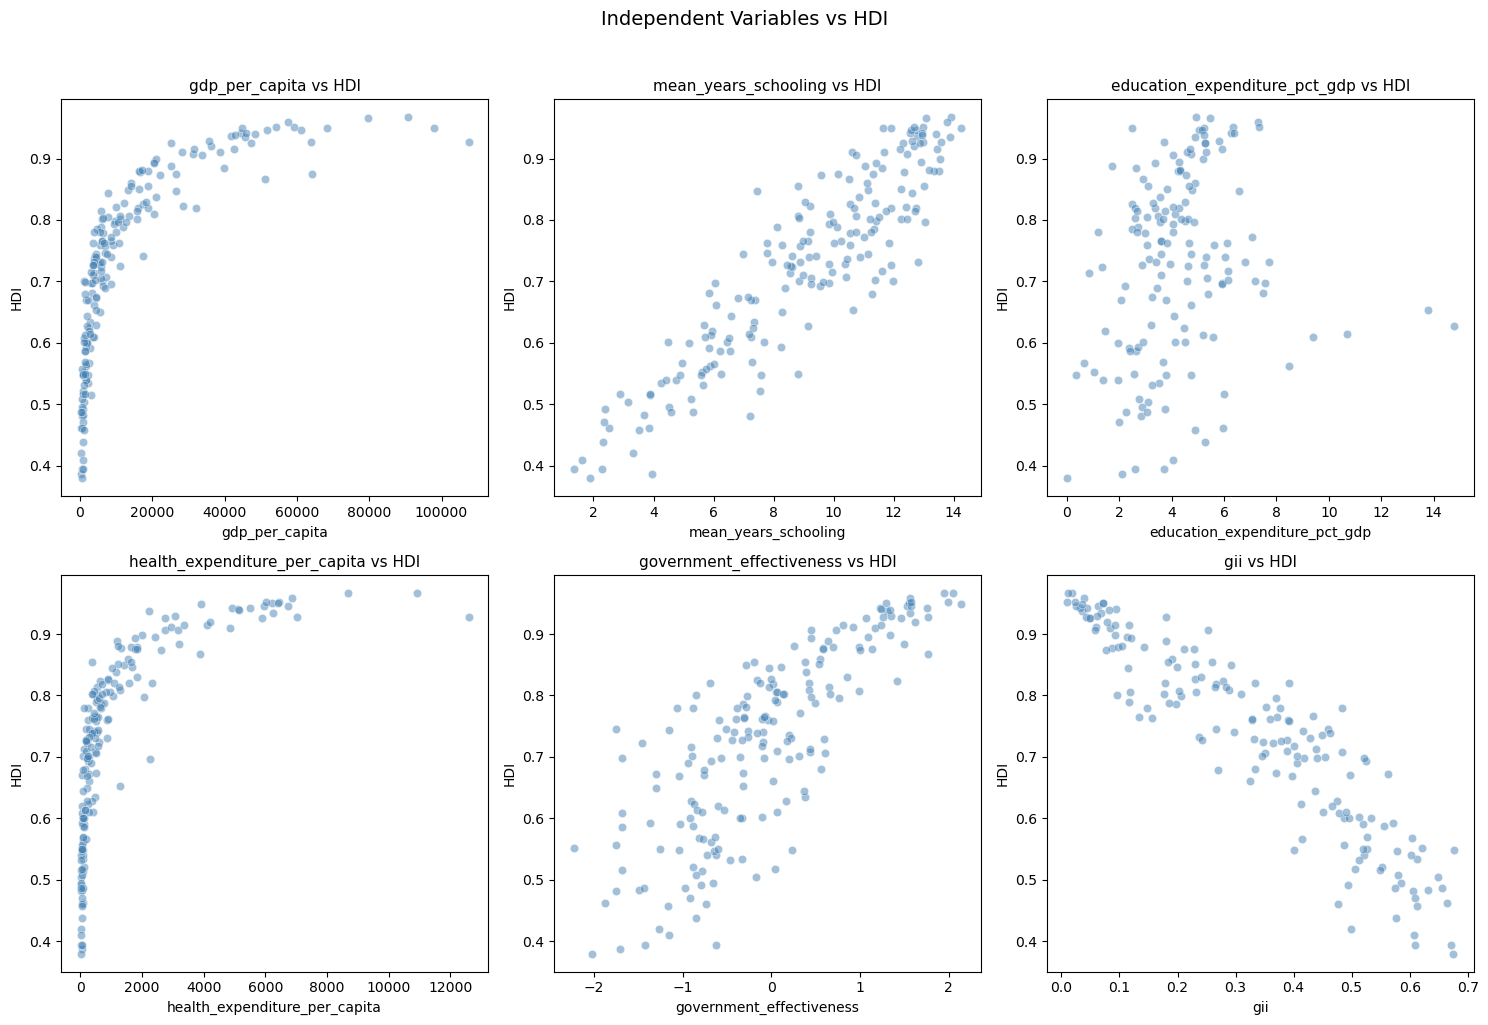

In [ ]:
# Scatter plots against HDI 
ind_vars = ['gdp_per_capita', 'mean_years_schooling',
            'education_expenditure_pct_gdp', 'health_expenditure_per_capita',
            'government_effectiveness', 'gii']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(ind_vars):
    axes[i].scatter(master[var], master['hdi'], 
                    alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('HDI', fontsize=10)
    axes[i].set_title(f'{var} vs HDI', fontsize=11)

plt.suptitle('Independent Variables vs HDI', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Key Finding: Bivariate Linearity Validation (Scatter Plots)

**Logarithmic Signal Decay:** The curved relationships in the GDP and Health plots confirm that gains in development "flatten" at higher expenditure levels. This provides the empirical evidence required to justify the Log-Transformation Layer used in the OLS pipeline.

**Linear Anchors:** mean_years_schooling and gii exhibit high linear stability, confirming their role as the Primary Linear Predictors for the structural model.

## EDA Summary & Modeling Specifications
The structural audit of the dataset defines four critical design requirements for the validation pipeline:

**Signal Linearization (Variable Transformations)**
gdp_per_capita and health_expenditure exhibit heavy right-skewness and "diminishing returns." Both will be log-transformed to stabilize variance and ensure a linear relationship with HDI.

**Redundancy Management (Multicollinearity Audit)**
High inter-correlations (0.91) between GDP and Health suggest functional redundancy. A formal VIF Audit is required in the next phase to ensure stable coefficient attribution.

**Feature Sensitivity (Education Expenditure)**
education_expenditure_pct_gdp shows a weak association (0.18). It is retained for structural completeness, though expectations for statistical significance remain low.

**Primary Structural Anchors**
mean_years_schooling (0.91) and gii (–0.92) emerge as the strongest linear predictors. Both display high-integrity linear trends and require no transformation for the final model.